# Optimización Bayesiana de hiperparámetros

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/teorico_practicos/Semana03_opt_bayesiana.ipynb)

In [ ]:
!pip install -q deepxde

In [ ]:
import os
# necesario para obligar a deepxde a usar el framework de pytorch. 
os.environ['DDE_BACKEND'] = "pytorch" 

import deepxde as dde
from matplotlib import pyplot as plt
import numpy as np
import skopt
from skopt import gp_minimize
from skopt.plots import plot_convergence, plot_objective
from skopt.space import Real, Categorical, Integer
from skopt.utils import use_named_args
import torch
torch.set_default_device("cpu")

if dde.backend.backend_name == "pytorch":
    sin = dde.backend.pytorch.sin
    pi = torch.pi
elif dde.backend.backend_name == "paddle":
    sin = dde.backend.paddle.sin
else:
    from deepxde.backend import tf
    sin = tf.sin
    pi = tf.constant(np.pi, dtype=tf.float32)

## Introducción

En esta notebook vamos a resolver el problema de inversión para la ecuación de Poisson 1D en donde no conocemos el campo de fuerza, i.e.

$$
\frac{d^2u}{dx^2} = q(x), \, x\in [-1,1]
$$
La función `pde(x, y)` define el residuo físico que la red debe minimizar. Para eso calcula la segunda derivada de la salida respecto de la entrada, $u''(x)$, y arma el residuo de la ecuación.

La función `sol_exacta(x)` no se usa para entrenar directamente toda la solución, sino como referencia para:

- generar algunos datos observados,
- evaluar el error de prueba,
- comparar la solución aproximada con la exacta al final.

In [34]:
def pde(x, y):
    u, q = y[:, 0:1], y[:,1:2] #ambas u y q son desconocidas
    dy_xx = dde.grad.hessian(y, x, component=0, i=0, j=0)
    return dy_xx - q

def sol_exacta(x):
    return np.sin(np.pi * x)

## Condiciones de contorno y datos observados

Acá se construyen las restricciones que acompañan a la ecuación, exactamente como hemos hecho antes:

- `contorno` identifica si un punto pertenece al borde del dominio.
- `func_contorno` fija el valor de la solución en el contorno, en este caso $u=0$.
- `x_train` y `y_train` agregan puntos observados dentro del dominio, lo que ayuda a guiar el entrenamiento de la PINN.



In [35]:
#  auxiliar para los puntos en el contorno
def contorno(x, en_contorno):
    return en_contorno


# función auxiliar para los valores en el contorno
def func_contorno(x):
    return 0

Supongamos que tenemos solo los datos de entrenamiento en puntos equiespaciados entre -1 y 0. 

In [36]:
x_train = np.linspace(-1, 0, 10).reshape(-1, 1)
y_train = sol_exacta(x_train)
geom = dde.geometry.Interval(-1, 1)
observe_u = dde.icbc.PointSetBC(x_train, y_train, component=0)
bc = dde.DirichletBC(geom, func_contorno, contorno)

## Construcción del modelo PINN

La función `create_model(config)` recibe una configuración de hiperparámetros y arma una PINN completa. En esta etapa se definen:

- el objeto `data`, que contiene la ecuación diferencial, las condiciones y la discretización del dominio;
- la arquitectura de la red neuronal totalmente conectada;
- el optimizador Adam y la métrica de error relativo $L^2$.

Esto es importante porque la optimización bayesiana va a probar muchas configuraciones distintas, y en cada intento necesita reconstruir el modelo con otros hiperparámetros.

In [42]:
def create_model(config):
    learning_rate, num_dense_layers, num_dense_nodes, activation = config

    data = dde.data.PDE(
        geom,
        pde,
        [observe_u, bc],
        num_domain=16,
        num_boundary=2,
        solution=sol_exacta,
        # anchors=x_train,
        num_test=100,
    )

    net = dde.maps.FNN(
        [1] + [num_dense_nodes] * num_dense_layers + [2],
        activation,
        "Glorot uniform",
    )

    model = dde.Model(data, net)
    model.compile("adam", lr=learning_rate, metrics=["l2 relative error"])
    return model, data

## Entrenamiento y función de costo

`train_model` ejecuta el entrenamiento durante un número fijo de iteraciones y recupera el historial de pérdidas. El valor que finalmente se devuelve como `error` es el mínimo de la pérdida de prueba.

Ese escalar resume qué tan bien funcionó una configuración dada y será la cantidad que la optimización bayesiana intentará **minimizar**.

In [65]:
def train_model(model, config, iterations=4000):
    losshistory, train_state = model.train(iterations=iterations)
    train = np.array(losshistory.loss_train).sum(axis=1).ravel()
    test = np.array(losshistory.loss_test).sum(axis=1).ravel()
    metric = np.array(losshistory.metrics_test).sum(axis=1).ravel()

    error = test.min()
    return error, losshistory, train_state

## Espacio de búsqueda de hiperparámetros

En esta sección se define qué aspectos del modelo se van a optimizar:

- `learning_rate`: tasa de aprendizaje del optimizador.
- `num_dense_layers`: cantidad de capas ocultas.
- `num_dense_nodes`: cantidad de neuronas por capa.
- `activation`: función de activación.

También se fija `default_parameters`, que sirve como punto inicial conocido para arrancar la búsqueda. Este espacio mezcla variables continuas, enteras y categóricas, algo que `skopt` maneja de forma directa.

In [44]:
n_calls = 15
dim_learning_rate = Real(low=1e-4, high=5e-2, name="learning_rate", prior="log-uniform")
dim_num_dense_layers = Integer(low=1, high=6, name="num_dense_layers")
dim_num_dense_nodes = Integer(low=5, high=50, name="num_dense_nodes")
dim_activation = Categorical(categories=["sin", "sigmoid", "tanh"], name="activation")

dimensions = [
    dim_learning_rate,
    dim_num_dense_layers,
    dim_num_dense_nodes,
    dim_activation,
]

default_parameters = [1e-3, 4, 50, "sin"]

## Función objetivo para la optimización bayesiana

La función `fitness(...)` es la interfaz entre la PINN y el optimizador bayesiano. Para cada conjunto de hiperparámetros:

1. arma una configuración,
2. crea el modelo correspondiente,
3. lo entrena,
4. devuelve el error obtenido.

`@use_named_args` permite que `skopt` pase los parámetros en forma clara según los nombres definidos en `dimensions`. Además, si aparece un `NaN`, se reemplaza por una penalización grande para que esa configuración quede descartada por el algoritmo.

In [45]:
@use_named_args(dimensions=dimensions)
def fitness(learning_rate, num_dense_layers, num_dense_nodes, activation):
    config = [learning_rate, num_dense_layers, num_dense_nodes, activation]
    global ITERATION

    print(ITERATION, "it number")
    # Print the hyper-parameters.
    print("learning rate: {0:.1e}".format(learning_rate))
    print("num_dense_layers:", num_dense_layers)
    print("num_dense_nodes:", num_dense_nodes)
    print("activation:", activation)
    print()

    # Create the neural network with these hyper-parameters.
    model, _ = create_model(config)
    # possibility to change where we save
    error, _, _ = train_model(model, config)
    # print(accuracy, 'accuracy is')

    if np.isnan(error):
        error = 10**5

    ITERATION += 1
    return error

## Búsqueda bayesiana de la mejor configuración

`gp_minimize` implementa la optimización bayesiana modelando la función objetivo con un **proceso gaussiano**. En cada iteración usa la información acumulada de evaluaciones anteriores para decidir qué combinación probar después.

La función de adquisición `EI` (**Expected Improvement**) favorece puntos que prometen mejorar el mejor resultado actual, equilibrando exploración y explotación. Al terminar, `search_result.x` contiene los mejores hiperparámetros encontrados y `search_result.fun` el mejor error asociado.

In [46]:
ITERATION = 0

search_result = gp_minimize(
    func=fitness,
    dimensions=dimensions,
    acq_func="EI",  # Expected Improvement.
    n_calls=n_calls,
    x0=default_parameters,
    random_state=1234,
)

best_params = search_result.x
best_score = search_result.fun

0 it number
learning rate: 1.0e-03
num_dense_layers: 4
num_dense_nodes: 50
activation: sin

Compiling model...
'compile' took 0.000084 s

Training model...

Step      Train loss                        Test loss                         Test metric   
0         [3.81e-02, 5.33e-01, 1.81e-02]    [3.14e-02, 5.33e-01, 1.81e-02]    [1.36e+00]    
1000      [2.34e-03, 1.60e-03, 4.52e-06]    [2.00e-03, 1.60e-03, 4.52e-06]    [1.06e+01]    
2000      [1.65e-04, 5.57e-04, 1.41e-05]    [1.76e-04, 5.57e-04, 1.41e-05]    [1.08e+01]    
3000      [2.69e-04, 3.07e-04, 1.07e-05]    [2.83e-04, 3.07e-04, 1.07e-05]    [1.10e+01]    
4000      [1.17e-03, 2.65e-04, 8.16e-06]    [1.05e-03, 2.65e-04, 8.16e-06]    [1.09e+01]    

Best model at step 3000:
  train loss: 5.87e-04
  test loss: 6.00e-04
  test metric: [1.10e+01]

'train' took 8.067976 s

1 it number
learning rate: 2.2e-03
num_dense_layers: 5
num_dense_nodes: 33
activation: tanh

Compiling model...
'compile' took 0.000094 s

Training model...

Step

## Reentrenamiento con la mejor configuración

Una vez terminada la búsqueda, se vuelve a crear la PINN usando los hiperparámetros óptimos y se la entrena otra vez. Esto permite disponer del modelo final para hacer predicciones, comparar con la solución exacta y analizar visualmente el resultado.

In [66]:
print("Best params:", best_params)
print("Best score:", best_score)
modelo, data = create_model(best_params)
error, losshistory, train_state = train_model(modelo, best_params, iterations=10000)

Best params: [0.0007674054502520459, 5, 34, 'sin']
Best score: 0.0003437009
Compiling model...
'compile' took 0.000087 s

Training model...

Step      Train loss                        Test loss                         Test metric   
0         [2.67e-02, 5.60e-01, 2.38e-02]    [2.38e-02, 5.60e-01, 2.38e-02]    [1.53e+00]    
1000      [1.15e-04, 7.81e-04, 1.82e-05]    [1.04e-04, 7.81e-04, 1.82e-05]    [1.09e+01]    
2000      [5.00e-04, 5.76e-04, 1.59e-05]    [5.76e-04, 5.76e-04, 1.59e-05]    [1.11e+01]    
3000      [3.24e-05, 4.69e-04, 2.67e-05]    [4.63e-05, 4.69e-04, 2.67e-05]    [1.12e+01]    
4000      [2.12e-05, 4.26e-04, 2.39e-05]    [3.28e-05, 4.26e-04, 2.39e-05]    [1.12e+01]    
5000      [2.14e-04, 3.85e-04, 8.42e-06]    [2.17e-04, 3.85e-04, 8.42e-06]    [1.12e+01]    
6000      [1.33e-05, 3.17e-04, 1.69e-05]    [2.39e-05, 3.17e-04, 1.69e-05]    [1.12e+01]    
7000      [1.05e-05, 2.92e-04, 1.66e-05]    [1.95e-05, 2.92e-04, 1.66e-05]    [1.12e+01]    
8000      [2.24e-05, 2

## Evaluación sobre puntos del dominio

Acá se generan puntos del intervalo para inspeccionar la solución aprendida. Se calculan:

- las predicciones en los puntos observados,
- las predicciones en una malla más densa del dominio,
- los valores exactos para comparar.

Con esto se puede verificar si la red reproduce correctamente la forma esperada de la solución de la PDE.

In [67]:
x = geom.uniform_points(50, True)
X_domain = data.train_x[:data.num_domain]
y_pred_train = modelo.predict(x_train)
y_exact_train = sol_exacta(x_train)

y_pred = modelo.predict(x)
y_exact = sol_exacta(x)

## Visualización de la solución y del proceso de optimización

Las últimas celdas muestran dos tipos de resultados:

- la comparación entre solución exacta, predicción de la PINN y puntos usados en el entrenamiento;
- la evolución de la optimización bayesiana mediante `plot_convergence` y `plot_objective`.

La primera figura sirve para validar la aproximación física. Las otras ayudan a entender si la búsqueda de hiperparámetros convergió y cómo influyó cada variable sobre el desempeño del modelo.

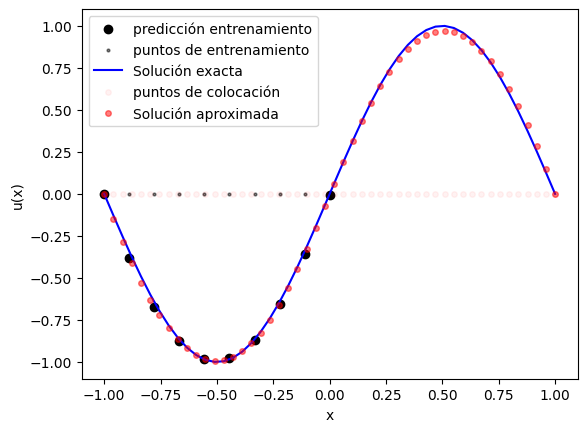

In [68]:
plt.figure()
plt.scatter(x_train, y_pred_train[:,0], color='black', label="predicción entrenamiento")
plt.scatter(x_train, np.zeros_like(x_train), color='black', label="puntos de entrenamiento", alpha=0.5, s=4)
plt.plot(x, y_exact, 'b', label="Solución exacta")
plt.plot(x, np.zeros_like(x), 'or', label="puntos de colocación", alpha=0.05, ms=4)
plt.plot(x, y_pred[:,0], 'or', label="Solución aproximada", alpha=0.5, ms=4)
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()
plt.show()


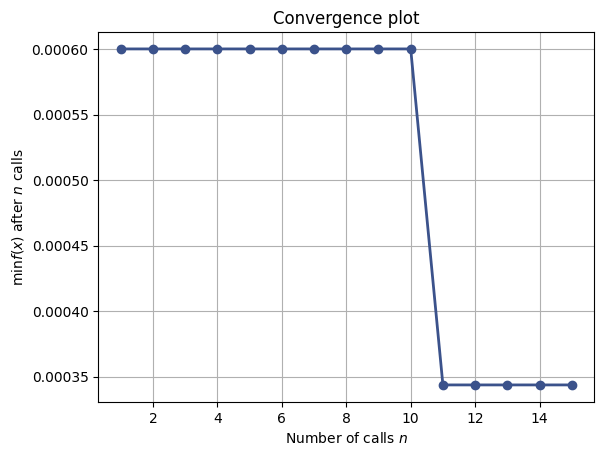

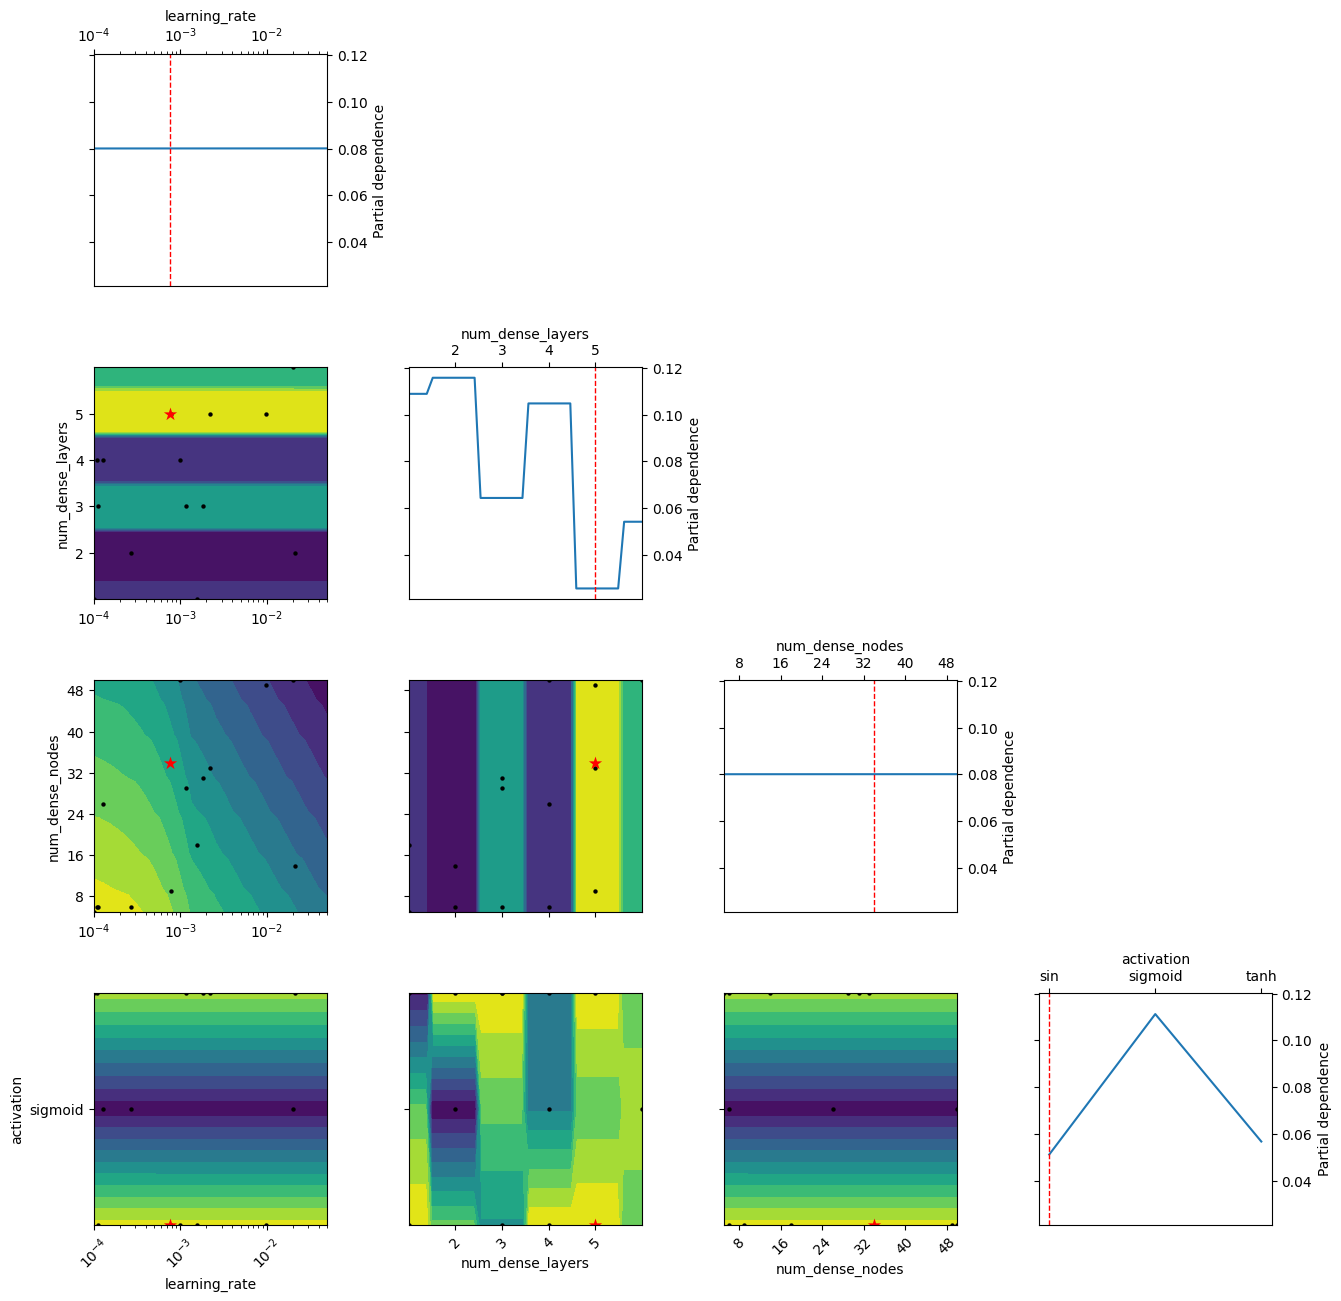

In [69]:
plot_convergence(search_result)
plt.show()
plot_objective(search_result, show_points=True, size=3.8)
plt.show()

Vemos la estimación del campo de fuerza

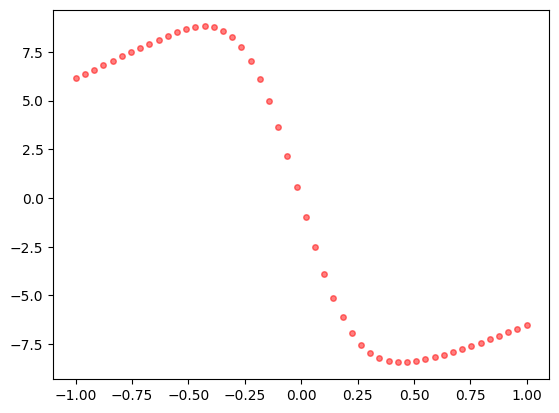

In [ ]:
plt.plot(x, y_pred[:,1], 'or', label="Solución aproximada", alpha=0.5, ms=4)
plt.show()